# Week_2 Assignment:

# Tesla Delivery Analysis and Prediction Pipeline

* This project focuses on analyzing Tesla delivery data from 2015–2025 using Python and machine learning techniques. The dataset is explored through data preprocessing, visualization, feature engineering, and predictive modeling. Linear Regression and Random Forest models are developed and evaluated using different performance metrics to understand delivery patterns and build an accurate prediction system.

# 1. Loading the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

print("Shape:", df.shape)

display(df.head())

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
print("\nColumns:")
display(pd.DataFrame(df.columns, columns=["Column Names"]))

print("\nInfo:")
df.info()

print("\nSummary Statistics:")
display(df.describe())


Columns:


,Column Names
0,Year
1,Month
2,Region
3,Model
4,Estimated_Deliveries
5,Production_Units
6,Avg_Price_USD
7,Battery_Capacity_kWh
8,Range_km
9,CO2_Saved_tons



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

Summary Statistics:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


* The Tesla deliveries dataset was loaded into a pandas DataFrame. The dataset contains delivery, production, pricing, battery, range, CO₂ savings, charging station, model, and region information from 2015–2025 used for further analysis.

# 2. Missing values and Duplicate rows

In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total Missing Values: 0

Duplicate Rows: 0


* Before further analysis, the dataset was checked for missing values and duplicate rows for a clean data. No major data quality issues were observed in the dataset, so we move to the further step.

# 3. EDA Chart Analysis

# Chart 1: Deliveries by Model

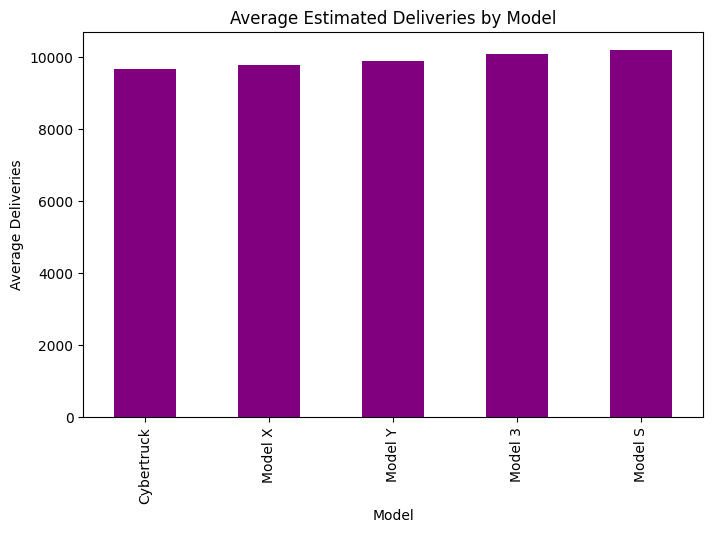

In [4]:
plt.figure(figsize=(8,5))

df.groupby("Model")["Estimated_Deliveries"].mean().sort_values().plot(kind="bar",color="Purple")

plt.title("Average Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Average Deliveries")

plt.show()

* The bar chart compares the average estimated deliveries across different Tesla models. It helps identify which models have higher average delivery volumes.

# Chart 2: Deliveries by Region

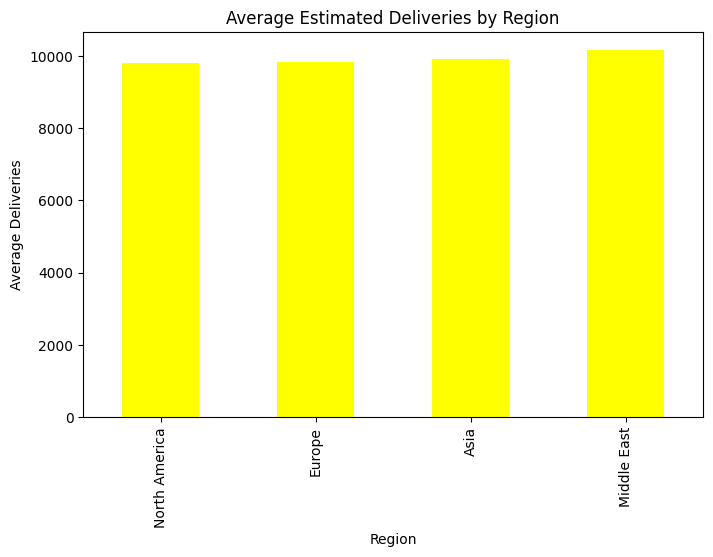

In [5]:
plt.figure(figsize=(8,5))

df.groupby("Region")["Estimated_Deliveries"].mean().sort_values().plot(kind="bar",color="yellow")

plt.title("Average Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Average Deliveries")

plt.show()

* The regional delivery chart compares average estimated deliveries across different regions. It provides insights into regional delivery performance.

# Chart 3: Correlation Heatmap

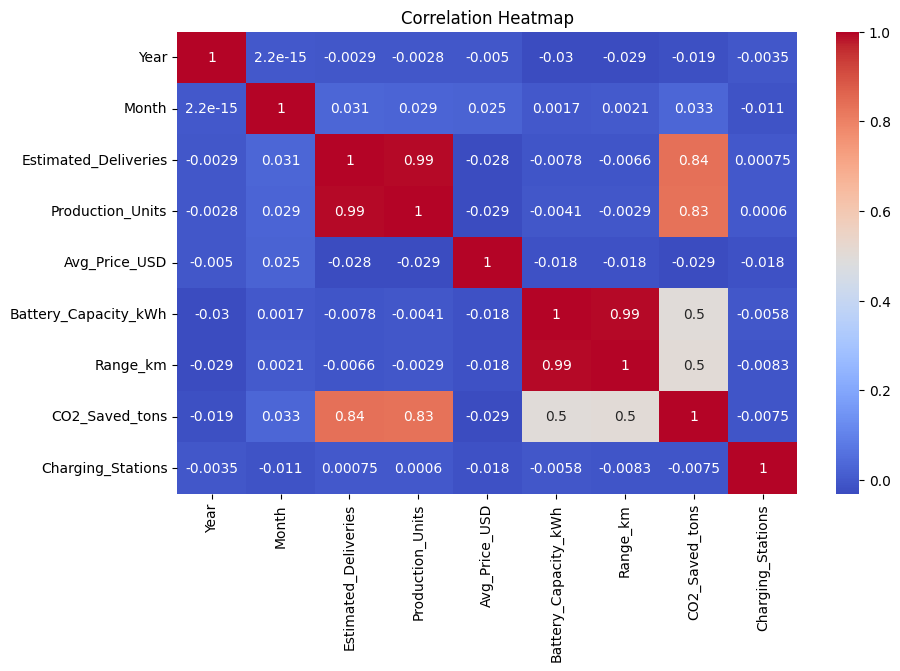

In [6]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

* The correlation heatmap shows relationships among numerical variables. Production_Units and Estimated_Deliveries exhibit a very strong positive correlation.

# Chart 4: Production vs Deliveries Scatter Plot

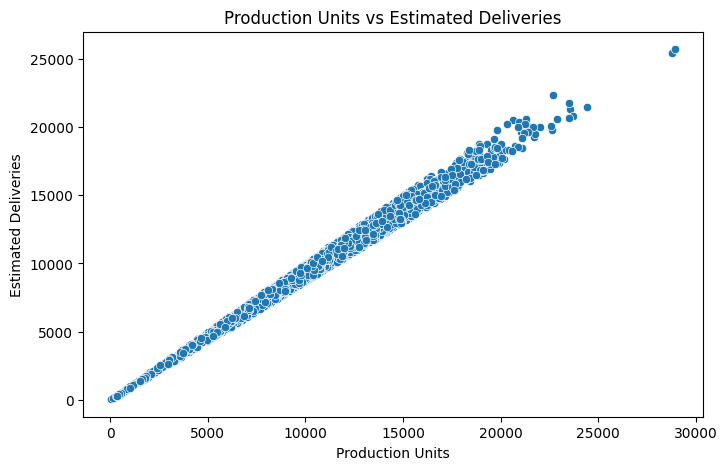

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.show()

* The scatter plot illustrates the relationship between production units and estimated deliveries. The strong positive trend indicates that higher production generally results in higher deliveries.

# Chart 5: Time-Trend Line

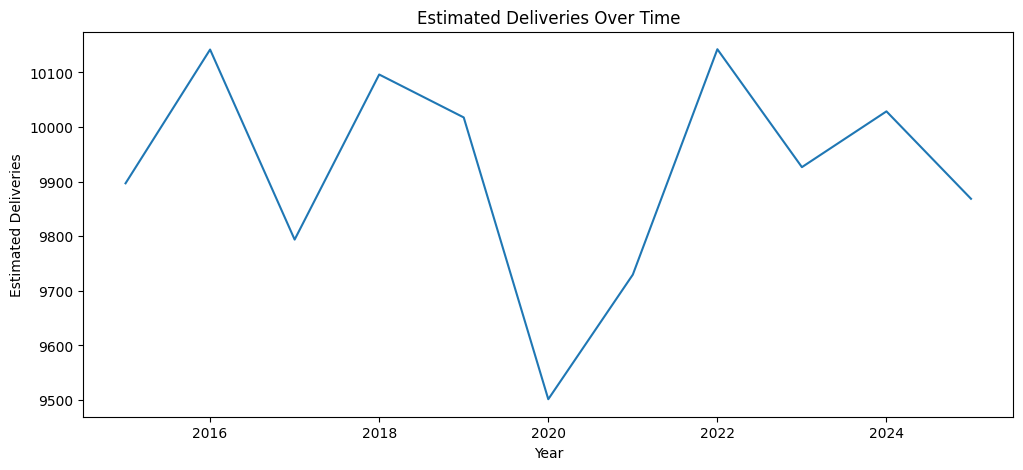

In [8]:
yearly_trend = (
    df.groupby("Year")["Estimated_Deliveries"]
    .mean()
)

plt.figure(figsize=(12,5))

yearly_trend.plot()

plt.title("Estimated Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.show()

* The yearly trend line shows how average estimated deliveries changed over time. It helps identify overall delivery patterns across different years.

# 5. Label Encoding 

In [9]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


# Lag Mean

In [10]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean())

# Rolling Mean

In [11]:
df["Rolling_Mean_3"] = (df["Estimated_Deliveries"].rolling(window=3).mean())

df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean())

In [12]:
print(df[["Estimated_Deliveries","Deliveries_Lag1","Rolling_Mean_3"]].head())

print(df[["Deliveries_Lag1","Rolling_Mean_3"]].isnull().sum())

   Estimated_Deliveries  Deliveries_Lag1  Rolling_Mean_3
0                 17646      9924.959454     9923.677407
1                  3797     17646.000000     9923.677407
2                  8411      3797.000000     9951.333333
3                  6555      8411.000000     6254.333333
4                 12374      6555.000000     9113.333333
Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


* The categorical columns Region, Model, and Source_Type were converted into numerical values using the LabelEncoder technique. This transformation makes the categorical information suitable for machine learning algorithms while preserving all records in the dataset. The encoded features are then used for further analysis and model training.
* Additionally, **Deliveries_Lag1** and **Rolling_Mean_3** were created to capture previous and short-term delivery trends, with missing values replaced using the respective column mean.

# 6. Chronological 80/20 Split

In [13]:
X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (2112, 13)
Test Shape: (528, 13)


* The dataset was divided into training and testing sets using an 80:20 ratio while preserving the chronological order of the observations. This approach helps prevent data leakage when working with time-related data.
* A Linear Regression model was trained using the selected input features to predict Estimated_Deliveries.
* The trained model was then used to generate predictions on the testing dataset for performance evaluation.

LINEAR REGRESSION:

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Model Trained")

Linear Regression Model Trained


MAE, RMSE & R² scores:

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

r2_lr = r2_score(y_test, pred_lr)

print("MAE :", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("R²  :", round(r2_lr, 4))

MAE : 310.3345
RMSE: 375.5647
R²  : 0.9908


# 7. Actual vs Predicted Scatter Plot

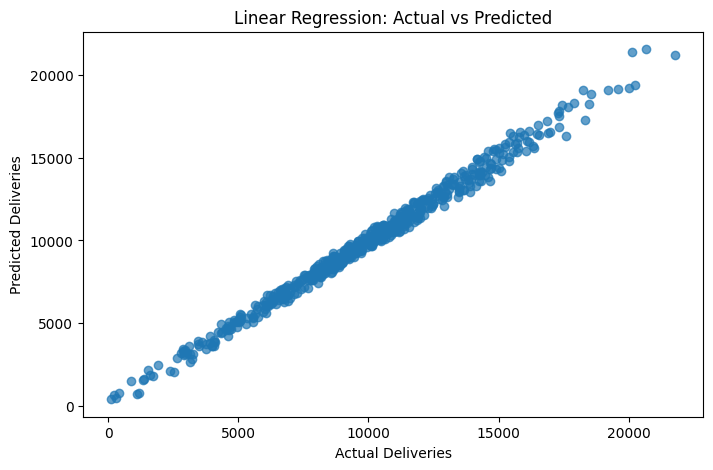

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    pred_lr,
    alpha=0.7
)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

* The scatter plot compares the actual delivery values with the values predicted by the Linear Regression model. Most data points are concentrated close to the diagonal pattern, indicating that the predicted values closely match the actual observations.

# 8. 5-Fold Cross Validation

In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Fold Scores:")
print(cv_scores)

print("\nMean R²:", cv_scores.mean())
print("Std Dev :", cv_scores.std())

Fold Scores:
[0.99080956 0.99007585 0.99047382 0.98903517 0.9908592 ]

Mean R²: 0.9902507187725078
Std Dev : 0.0006693958686634296


* Five-fold cross-validation was performed for evaluating the reliability and stability of the Linear Regression model. First, the dataset was divided into five equal parts, and then the model was trained and tested multiple times using different folds. The consistently high Mean R² scores obtained across all folds indicate that the model performs well on unseen data. The low Std Dev also suggests that the model produces consistent results.

# 9. Random Forest and GridSearchCV

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

rf = RandomForestRegressor(
    random_state=42
)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}


MODEL & EVALUATIONS:

In [19]:
best_rf = grid.best_estimator_

pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)

r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Results")
print("MAE :", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R²  :", round(r2_rf, 4))

Random Forest Results
MAE : 303.8583
RMSE: 388.5513
R²  : 0.9902


* A Random Forest model was optimized using GridSearchCV by testing combinations of **n_estimators** and **max_depth**. The best-performing model was selected, evaluated using MAE, RMSE, and R². 

# 10. Top 10 Feature Importances

*The contribution of each feature was evaluated using the Random Forest model. The results indicate that Production_Units has the greatest influence on predicting estimated deliveries, while the remaining features have comparatively smaller effects.*

In [20]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(10))

,Feature,Importance
4,Production_Units,0.990055
8,CO2_Saved_tons,0.002163
7,Range_km,0.001221
5,Avg_Price_USD,0.001040
10,Charging_Stations,0.001004
12,Rolling_Mean_3,0.000955
11,Deliveries_Lag1,0.000923
0,Year,0.000888
1,Month,0.000668
3,Model,0.000357


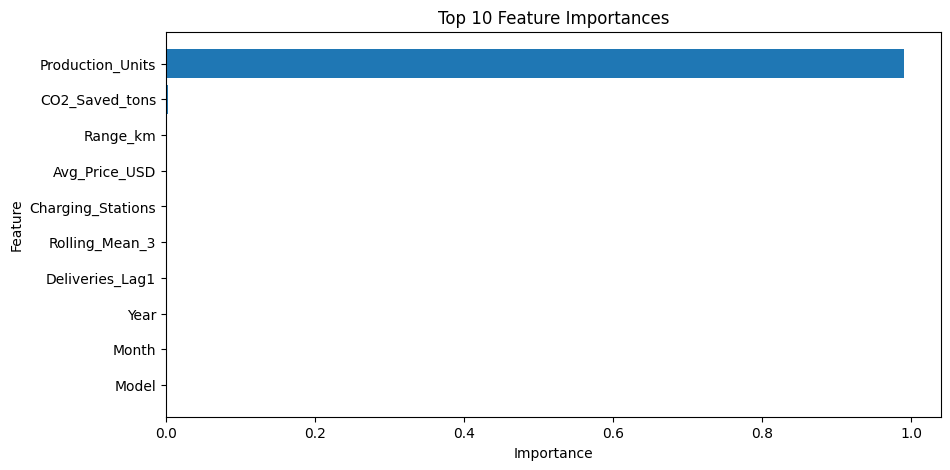

In [21]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

# 11. ADF Test

In [22]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(
    df["Estimated_Deliveries"]
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -53.82661259715622
p-value: 0.0
Series is Stationary


* The stationarity of the Estimated_Deliveries series was verified using the ADF test. Since the obtained p-value is below the significance level of 0.05, the data is considered stationary and does not contain a unit root.

# 12. Forecast Table

In [23]:
forecast_table = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": pred_rf[:20]
})

forecast_table["Error_%"] = (
    abs(
        forecast_table["Actual"]
        -
        forecast_table["Predicted"]
    )
    /
    forecast_table["Actual"]
) * 100

display(forecast_table)

,Actual,Predicted,Error_%
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


* A comparison of actual and predicted delivery values was performed along with their percentage errors. Most observations have relatively small errors, indicating that the trained model predicts delivery values with good accuracy.

# 13. Model Comparison

*The prediction performance of Linear Regression and Random Forest using MAE, RMSE, and R² scores. Both models achieved excellent results, with only a slight difference in their overall performance on the test data.*

In [24]:
comparison_table = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_rf
    ]
})

display(comparison_table)

,Model,MAE,RMSE,R2
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


# Conclusion

This project successfully analyzed the Tesla deliveries dataset and demonstrated the complete machine learning workflow, including data preprocessing, visualization, feature engineering, model training, and evaluation. Both Linear Regression and Random Forest models achieved excellent prediction accuracy with R² values close to 0.99. The analysis also showed that Production_Units is the most significant factor affecting estimated deliveries, while the ADF test confirmed that the delivery time series is stationary. Overall, the developed pipeline provides reliable predictions and valuable insights into Tesla's delivery trends.